In [26]:
import numpy as numpy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [27]:
df_train = pd.read_csv('data/train.csv')

In [28]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())

In [29]:

df_train['Embarked']=df_train['Embarked'].fillna(df_train['Embarked'].mode())

In [30]:
df_train['Age']=df_train['Age'].astype(int)

In [31]:
df_train = df_train.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1)

In [32]:
df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\simoen\AppData\Local\Temp\ipykernel_13168\1220814546.py:1: SyntaxWarning: invalid escape sequence '\.'
  df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [33]:

df_train=pd.get_dummies(df_train,drop_first=True)

In [34]:
df_train['fare_bin'] = pd.qcut(df_train['Fare'], q=4, labels=False)

In [35]:
df_train['family']=df_train['SibSp']+df_train['Parch']

In [36]:
df_train['Age_bin'] = pd.qcut(df_train['Age'], q=4, labels=False)

In [37]:
df_train['Alone'] = (df_train['SibSp'] == 0)&(df_train['Parch'] == 0)

In [38]:
Q1_age = df_train['Age'].quantile(0.25)
Q2_age = df_train['Age'].quantile(0.5)
Q3_age = df_train['Age'].quantile(0.75)
max_age = df_train['Age'].max()

In [39]:
def age_category(age):
    if age <= Q1_age:
        return 0
    elif age <= Q2_age:
        return 1
    elif age <= Q3_age:
        return 2
    else:
        return 3
df_train['Age_cat'] = df_train['Age'].apply(age_category)

In [40]:
Q1_fare = df_train['Fare'].quantile(0.25)
Q2_fare = df_train['Fare'].quantile(0.5)
Q3_fare = df_train['Fare'].quantile(0.75)
max_fare = df_train['Fare'].max()

In [41]:
def fare_category(fare):
    if fare <= Q1_fare:
        return 0
    elif fare <= Q2_fare:
        return 1
    elif fare <= Q3_fare:
        return 2
    else:
        return 3
df_train['Fare_cat'] = df_train['Fare'].apply(fare_category)

In [42]:
x_train = df_train.drop('Survived', axis=1)
y_train = df_train['Survived']
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score,precision_score, recall_score
from sklearn.model_selection import GridSearchCV
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Logistic Regression Confusion Matrix:
[[92 13]
 [21 53]]
Logistic Regression Accuracy: 0.8100558659217877
Logistic Regression F1 Score: 0.7571428571428571
Logistic Regression Precision: 0.803030303030303
Logistic Regression Recall: 0.7162162162162162


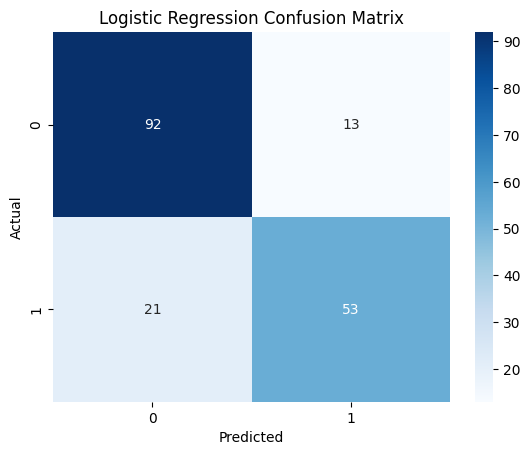

In [43]:

model_lr = LogisticRegression()
model_lr.fit(x_train_scaled, y_train)
y_pred_lr = model_lr.predict(x_test_scaled)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression F1 Score:", f1_score(y_test, y_pred_lr))
print("Logistic Regression Precision:", precision_score(y_test, y_pred_lr))
print("Logistic Regression Recall:", recall_score(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [44]:
x_train_acc = accuracy_score(y_test, y_pred_lr)
x_test_acc = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Train Accuracy: {x_train_acc:.4f}")
print(f"Logistic Regression Test Accuracy: {x_test_acc:.4f}")

Logistic Regression Train Accuracy: 0.8101
Logistic Regression Test Accuracy: 0.8101


In [45]:
df_test = pd.read_csv('data/test.csv')

In [46]:
df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].mean())
df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())
df_test['Embarked']=df_test['Embarked'].fillna(df_test['Embarked'].mode())
df_test['Age']=df_test['Age'].astype(int)
df_test = df_test.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1)
df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
C:\Users\simoen\AppData\Local\Temp\ipykernel_13168\3383282570.py:6: SyntaxWarning: invalid escape sequence '\.'
  df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [47]:
df_test=pd.get_dummies(df_test,drop_first=True)
df_test['fare_bin'] = pd.qcut(df_test['Fare'], q=4, labels=False)
df_test['family']=df_test['SibSp']+df_test['Parch']
df_test['Age_bin'] = pd.qcut(df_test['Age'], q=4, labels=False)
df_test['Alone'] = (df_test['SibSp'] == 0)&(df_test['Parch'] == 0)

In [48]:
df_test['Age_cat'] = df_test['Age'].apply(age_category)
df_test['Fare_cat'] = df_test['Fare'].apply(fare_category)

In [49]:
df = df_test.reindex(columns=x_train.columns, fill_value=0)
df_test_scaled = scaler.transform(df)

predictions_lr = model_lr.predict(df_test_scaled)
submission_lr = pd.DataFrame({
    'PassengerId': pd.read_csv('data/test.csv')['PassengerId'],
    'Survived': predictions_lr
})
submission_lr.to_csv('submission_lr.csv', index=False)